# DEF-D Fysieke Ontwerpopdracht 1 invul template

## Groepsgegevens en planning 

Aan het einde van deze ontwerpopdracht lever je als groep dit notebook gezamenlijk in via een pull request op Github en lever je een link naar dit pull request in op Brightspace. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan. Werk in de juiste branch.

| Groep: 10     |  |
| :-------------|:-------------|
| Bram Reekers| 6503721 |
| Meijne Bolger| 6213898|
| SAlesja Zorina| 6575129 |

| Planning Groep: 10     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1: Criteria opgesteld | 12±45|
| Mijlpaal 2: Eerste kalibratie meting gedaan| 14±30|
| Pauze 1| 12±30 / 13±30|
| Pauze 2| 15±00 tot 15±15 |

## *Opdracht 1*: Foto van alle schetsen.

Zet de foto in dezelfde map als dit notebook en verander hieronder de naam in de naam van de foto.

![Alt](11936.jpg "analyse: ideeen")

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Licht | Optimale hoek voor lichtinval (in lux) meten | De onzekerheid van de sensor mag niet groter dan 1% van zijn maximum zijn |
|Licht | Lamp aan/uit zetten op basis van verlichting van de omgeving | Moet de donkerste 12 uur en de lichtste 12 uur uit elkaar kunnen houden|
|Licht | Wekker af laten gaan bij zonlicht | Moet af kunnen gaan 50% boven het minimum|
|Temperatuur | Als thermometer gebruiken | Onzekerheid van 0.1 Graden |
|Temperatuur | Checken of een muizenhol bewoond is | Binnen 5 centimeter van de sensor het verschil tussen een warmbloedig dier en zijn omgeving meten |
|Temperatuur| Meter om te kijken of warme drank drinkbaar is  | Sensor die gevoelig is tussen 45 en 65 gradne celssius met ene onzekerheid van 2.5 graden |
| Druk | Weegschaal voor lichte voorwerpen | Meetbereik van 0.001 kg tot 0.100 kg onzekerheid van 0.0001 kg  |
| Druk | Hoogte bepalen aan de hand van de g (met blok van 1 kg) | Meetbereik rondom het gekozen gewicht (hoeft maar een klein meetinterval te zijn) onzekerheid zo klein dat schommelingen in de g opgemerkt kunnen worden |
| Druk | Meten hoe sterk een vrouwenduim is | Meetbereik van 40-100 N, onzekerheid van 1N  |

##

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Licht | Wekker af laten gaan bij zonlicht | De sensor moet een meetbereik hebben van 100 tot 400 lux met een onzekerheid van 10 lux, |
|Temperatuur| Meter om te kijken of warme drank drinkbaar is  | Sensor die gevoelig is tussen 45 en 65 gradne celssius met ene onzekerheid van 2.5 graden |
| Druk | Meten hoe sterk een vrouwenduim is | Meetbereik van 40-100 N, onzekerheid van 1N  |


Groep 10 heeft gekozen voor sensor licht. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](5ce31efe-5485-45e1-bdca-3fde2c34cf46~1.jpg "schets student")

## *Opdracht 4*: Beantwoord de vragen

1. Welke variabelen ga je veranderen?
De lichtintensiteit

2. Over welk bereik ga je deze variabelen veranderen?
van 0 tot 10000 lux

3. Wat ga je allemaal meten?
de lichtintensiteit en de spanning over de vaste weerstand 

4. Hoeveel metingen ga je doen?
3 per situatie, 7 situaties

5. Ga je met deze keuzes kunnen evalueren of jouw sensor geschikt is voor de gekozen toepassingen?
ja

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](PXL_20260218_140933623.jpg "meetopstelling student")



 ![Alt](PXL_20260218_152358628.jpg "meetopstelling student")

Meetplan:
1. bouw de schakeling met een LDR en een vaste weerstand hierin geschakeld
2. meet eerst de 'normale' situatie met de arduino en met de phyphox app op je telefoon en noteer metingen
3. doe de LDR en de telefoon in een doos, doe de doos dicht en noteer hier metingen van 
4. doe de doos steeds 10 graden verder open totdat 180 graden bereikt is en noteer de metingen

## *Opdracht 6*: Meten en fitten, Leerdoel

In [1]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

Bits = np.array([22,23,25,670,680,690,830,840,850,914,915,916,540,545,550,470,475,480,410,420,360,370,220,230,610,615,620])
Lumen = np.array([0,0,0,150,170,180,350,370,395,570,575,580,70,75,80,20,25,30,11,12,7,8,1,3,120,125,130])

print(len(Bits)==len(Lumen))

# Zet hier jouw data in een voor jou handig formaat



True


[0.00564672 3.33220628]


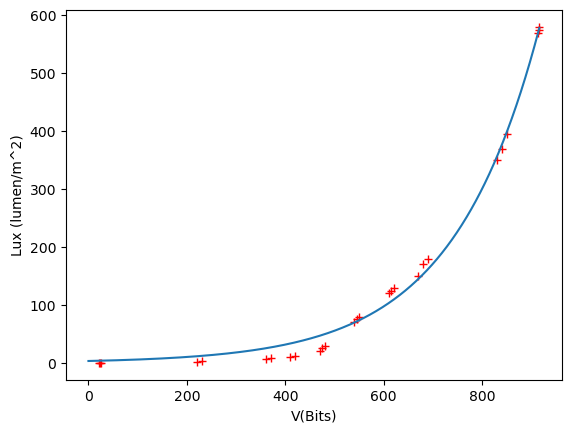

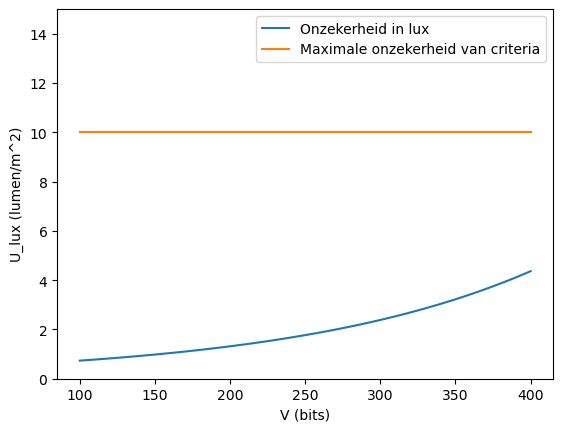

In [2]:
#curvefit, we fitten op basis van a * e**bx

def f(invoer,a,b):
    return b*(2.71**(invoer*a))

var,cov = curve_fit(f,Bits,Lumen,p0=[0.0073,1.01])

print(var)

#plotten van de functie 

plt.figure()
plt.plot(Bits,Lumen,"r+")

bits2 = np.linspace(0, np.max(Bits), 1000)
plt.plot(bits2,f(bits2,var[0],var[1]),label="Het gefitte verband")
plt.xlabel("V(Bits)")
plt.ylabel("Lux (lumen/m^2)")
plt.show()


u_a = np.sqrt(cov[0,0])
u_b = np.sqrt(cov[1,1])

# Foutpropagatie via calculusmethode op ieder punt (met bits als invoer en de onzekerheid op dat punt als uitvoer)

def u_lumen(Bits):
    df_da = var[1] * Bits * np.exp(var[0] * Bits)
    df_db = np.exp(var[0] * Bits)
    delta_f = np.sqrt((df_da * u_a)**2 + (df_db * u_b)**2)
    return delta_f

#plotten van de onzekerheid
bits3 = np.linspace(100,400,100)

def lijn(bits):
    return bits*0 + 10

plt.figure()
plt.plot(bits3,u_lumen(bits3), label='Onzekerheid in lux')
plt.plot(bits3,lijn(bits3), label='Maximale onzekerheid van criteria')
plt.ylim(0,15)
plt.xlabel("V (bits)")
plt.ylabel("U_lux (lumen/m^2)")
plt.legend()
plt.show()



## *Opdracht 7*: Iteratie nodig?

Uit onze metingen is een relatief duidelijk verband gekomen, dus iteratie is niet nodig.

## *Opdracht 8*: Conclusie, leerdoel

De gestelde criteria was dat de sensor een meetbereik tussen de 100 en 400 lux had met een onzekerheid van 10 lux. Onze metingen laat zien dat de sensor gebruikt kan worden voor de toepassing om een wekker af te laten gaan wanneer de zon opkomt. Ook de onzekerheid in onze metingen ligt binnen het bereik van de criteria. 

## *Opdracht 9*: Aantonen leerdoelen beheersing

Om aan te tonen dat je de leerdoelen beheerst, kopieer je hieronder alle cellen met 'leerdoel' in de titel. Zet zelf de cellen onder de goede kopjes. Mogelijk komt een cel bij meerdere leerdoelen terug.

### Leerdoel 1: Simpele circuits (RC-circuit, spanningsdelers met sensoren) ontwerpen en fabriceren.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 1 beheersen.

## *Opdracht 5*: Foto van jouw meetopstelling in. Leerdoel.
Licht kort toe wat er in de foto te zien is.
 ![Alt](PXL_20260218_140933623.jpg "meetopstelling student")

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](5ce31efe-5485-45e1-bdca-3fde2c34cf46~1.jpg "schets student")

### Leerdoel 2: Ontwerpeisen voor een opdracht SMART opstellen en vervolgens de ontwerpcyclus inrichten, rekening houdend met de randvoorwaarde van de opdracht.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 2 beheersen.

## *Opdracht 2*, MIJLPAAL, Leerdoel
Vul onderstaande tabel in en geef aan met welke sensor je verder gaat.** Laat dit aan je TA zien.** Als je TA druk is: ga wel ondertussen door met de volgende stap.

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Licht | Optimale hoek voor lichtinval (in lux) meten | De onzekerheid van de sensor mag niet groter dan 1% van zijn maximum zijn |
|Licht | Lamp aan/uit zetten op basis van verlichting van de omgeving | Moet de donkerste 12 uur en de lichtste 12 uur uit elkaar kunnen houden|
|Licht | Wekker af laten gaan bij zonlicht | Moet af kunnen gaan 50% boven het minimum|
|Temperatuur | Als thermometer gebruiken | Onzekerheid van 0.1 Graden |
|Temperatuur | Checken of een muizenhol bewoond is | Binnen 5 centimeter van de sensor het verschil tussen een warmbloedig dier en zijn omgeving meten |
|Temperatuur| Meter om te kijken of warme drank drinkbaar is  | Sensor die gevoelig is tussen 45 en 65 gradne celssius met ene onzekerheid van 2.5 graden |
| Druk | Weegschaal voor lichte voorwerpen | Meetbereik van 0.001 kg tot 0.100 kg onzekerheid van 0.0001 kg  |
| Druk | Hoogte bepalen aan de hand van de g (met blok van 1 kg) | Meetbereik rondom het gekozen gewicht (hoeft maar een klein meetinterval te zijn) onzekerheid zo klein dat schommelingen in de g opgemerkt kunnen worden |
| Druk | Meten hoe sterk een vrouwenduim is | Meetbereik van 40-100 N, onzekerheid van 1N  |

##

| Sensor | Toepassing | Criteria |
|:---|:---|:---|
|Licht | Wekker af laten gaan bij zonlicht | De sensor moet een meetbereik hebben van 100 tot 400 lux met een onzekerheid van 10 lux, |
|Temperatuur| Meter om te kijken of warme drank drinkbaar is  | Sensor die gevoelig is tussen 45 en 65 gradne celssius met ene onzekerheid van 2.5 graden |
| Druk | Meten hoe sterk een vrouwenduim is | Meetbereik van 40-100 N, onzekerheid van 1N  |


Groep 10 heeft gekozen voor sensor licht. 

### Leerdoel 3: Voor een gegeven sensor & analoog-digitaal convertor en gegeven (of zelf gekozen) toepassing een kalibratie meting ontwerpen, inclusief het circuit om de sensor aan te sluiten op de analoog-digitaal convertor, de opstelling bouwen, en meetresultaten verwerken en concluderen of de combinatie van sensor en analoog-digitaal conversie geschikt is voor de toepassing.

Kopieer hier de cel(len) waaruit blijkt dat jullie leerdoel 3 beheersen.

## *Opdracht 8*: Conclusie, leerdoel

De gestelde criteria was dat de sensor een meetbereik tussen de 100 en 400 lux had met een onzekerheid van 10 lux. Onze metingen laat zien dat de sensor gebruikt kan worden voor de toepassing om een wekker af te laten gaan wanneer de zon opkomt. Ook de onzekerheid in onze metingen ligt binnen het bereik van de criteria. 

## *Opdracht 3*: Foto van de schets van jouw meetopstelling in.
Licht kort toe wat er in de foto te zien is.
 ![Alt](5ce31efe-5485-45e1-bdca-3fde2c34cf46~1.jpg "schets student")

[0.00564672 3.33220628]


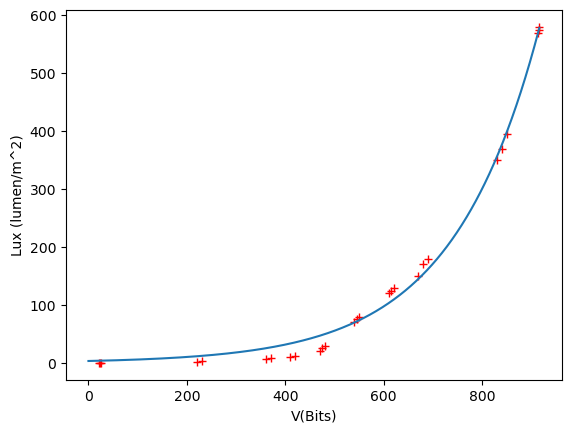

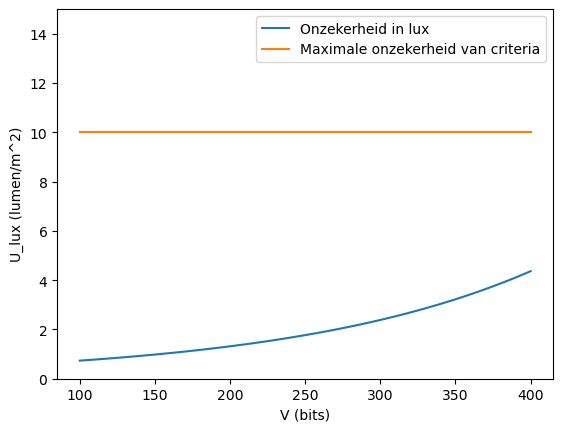

In [3]:
#curvefit

def f(invoer,a,b):
    return b*(2.71**(invoer*a))

var,cov = curve_fit(f,Bits,Lumen,p0=[0.0073,1.01])

print(var)

# Plot

plt.figure()
plt.plot(Bits,Lumen,"r+")

bits2 = np.linspace(0, np.max(Bits), 1000)
plt.plot(bits2,f(bits2,var[0],var[1]),label="Het gefitte verband")
plt.xlabel("V(Bits)")
plt.ylabel("Lux (lumen/m^2)")
plt.show()


u_a = np.sqrt(cov[0,0])
u_b = np.sqrt(cov[1,1])

# Foutpropagatie via calculusmethode op ieder punt (met bits als invoer en de onzekerheid op dat punt als uitvoer)

def u_lumen(Bits):
    df_da = var[1] * Bits * np.exp(var[0] * Bits)
    df_db = np.exp(var[0] * Bits)
    delta_f = np.sqrt((df_da * u_a)**2 + (df_db * u_b)**2)
    return delta_f

#plotten van de onzekerheid
bits3 = np.linspace(100,400,100)

def lijn(bits):
    return bits*0 + 10

plt.figure()
plt.plot(bits3,u_lumen(bits3), label='Onzekerheid in lux')
plt.plot(bits3,lijn(bits3), label='Maximale onzekerheid van criteria')
plt.ylim(0,15)
plt.xlabel("V (bits)")
plt.ylabel("U_lux (lumen/m^2)")
plt.legend()
plt.show()

